# 2026 March Madness Bracket Predictions

Use this notebook to explore 2026 NCAA Men's Tournament predictions from the latest model output.

The model uses ELO, heat momentum, team form, box score features, schedule strength, and lines context. Probabilities are calibrated and clipped in the production pipeline.

This notebook shows:
1. Team power rankings for seeded teams
2. Round-of-64 matchup probabilities by region
3. Cinderella watch using heat features
4. Head-to-head matchup explorer
5. Submission readiness checks

---

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import polars as pl

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
BASE = ROOT / "artifacts" / "latest"

# Load submission predictions
submission = pl.read_csv(BASE / "submission.csv")

# Load team metadata
teams = pl.read_csv(ROOT / "data" / "MTeams.csv").select("TeamID", "TeamName")
tid_to_name = dict(zip(teams["TeamID"].to_list(), teams["TeamName"].to_list()))

# Load 2026 seeds and slots
seeds_2026 = pl.read_csv(ROOT / "data" / "MNCAATourneySeeds.csv").filter(pl.col("Season") == 2026)
slots_2026 = pl.read_csv(ROOT / "data" / "MNCAATourneySlots.csv").filter(pl.col("Season") == 2026)

# Load team features for additional context
team_features = pl.read_parquet(BASE / "gold" / "team_season_features.parquet")
m_2026 = team_features.filter((pl.col("sex") == "M") & (pl.col("season") == 2026))

# Build seed -> team mapping
seed_to_team = {}
seed_to_name = {}
for row in seeds_2026.iter_rows(named=True):
    tid = row["TeamID"]
    seed_to_team[row["Seed"]] = tid
    seed_to_name[row["Seed"]] = tid_to_name.get(tid, str(tid))


def get_pred(tid_a: int, tid_b: int) -> float:
    """Get P(lower-ID team wins) from submission."""
    low, high = min(tid_a, tid_b), max(tid_a, tid_b)
    match = submission.filter(pl.col("ID") == f"2026_{low}_{high}")
    if match.height > 0:
        return float(match["Pred"][0])
    return 0.5


REGION_NAMES = {"W": "West", "X": "East", "Y": "South", "Z": "Midwest"}

print(f"Loaded {seeds_2026.height} seeded teams across 4 regions")
print(f"Loaded {slots_2026.height} bracket slots")
print(f"Submission has {submission.height:,} predictions")

Loaded 68 seeded teams across 4 regions
Loaded 67 bracket slots
Submission has 132,133 predictions


---

## Team Power Rankings

All 68 tournament teams ranked by season-end ELO rating. Higher ELO = stronger team based on regular season performance. Heat scores show recent momentum (positive = outperforming expectations).

In [2]:
# Power rankings: all 68 teams sorted by ELO
power = (
    m_2026
    .join(seeds_2026.select(
        pl.col("TeamID").cast(pl.Int64).alias("team_id"),
        pl.col("Seed"),
    ), on="team_id", how="inner")
    .join(teams.rename({"TeamID": "team_id"}), on="team_id", how="left")
    .sort("season_end_elo", descending=True)
)

print(f"{'#':>3} {'Seed':<6} {'Team':<22} {'ELO':>7} {'Record':>8} {'WR':>6} {'Margin':>7} {'SOS':>7} {'H-5g':>7} {'FG%':>6}")
print("─" * 95)
for i, row in enumerate(power.iter_rows(named=True), 1):
    record = f"{row['wins']}-{row['losses']}"
    h5 = row.get('pre_tourney_heat_5g') or 0
    elo = row.get('season_end_elo') or 1500
    sos = row.get('sos') or 0
    fg = row.get('fg_pct') or 0
    print(f"{i:>3} {row['Seed']:<6} {row['TeamName']:<22} {elo:>7.0f} {record:>8} {row['win_rate']:>5.1%} {row['avg_margin']:>+7.1f} {sos:>7.0f} {h5:>+7.1f} {fg:>5.1%}")

  # Seed   Team                       ELO   Record     WR  Margin     SOS    H-5g    FG%
───────────────────────────────────────────────────────────────────────────────────────────────
  1 W01    Duke                      1982     32-2 94.1%   +19.1    1616    +1.3 49.0%
  2 Z01    Arizona                   1948     32-2 94.1%   +17.4    1613    +0.7 50.2%
  3 Y01    Michigan                  1944     31-3 91.2%   +17.6    1637    -4.1 50.5%
  4 W05    St John's                 1883     28-6 82.4%   +11.6    1575    -1.6 45.4%
  5 X01    Florida                   1881     26-7 78.8%   +14.8    1620    +6.0 47.8%
  6 Z03    Gonzaga                   1869     30-3 90.9%   +19.1    1540    -1.1 51.0%
  7 X02    Houston                   1844     28-6 82.4%   +14.3    1600    +5.0 45.0%
  8 Y03    Virginia                  1838     29-5 85.3%   +12.2    1567    -5.4 46.3%
  9 Z02    Purdue                    1836     27-8 77.1%   +11.5    1621    -0.6 49.9%
 10 X07    St Mary's CA         

---

## Round of 64 — First Round Matchups by Region

Each region has 8 first-round games (1v16, 2v15, 3v14, ... 8v9). The model predicts the probability the higher-seeded team (stronger seed = lower number) wins.

**⚠️ Upset Alert** = model gives the lower-seeded team (underdog) a >35% chance of winning.

In [3]:
# First round matchups by region
first_round_slots = slots_2026.filter(pl.col("Slot").str.starts_with("R1")).sort("Slot")

for region_code, region_name in REGION_NAMES.items():
    region_slots = first_round_slots.filter(
        pl.col("Slot").str.contains(f"R1{region_code}")
    ).sort("Slot")

    print(f"\n{'=' * 78}")
    print(f"  {region_name.upper()} REGION ({region_code})")
    print(f"{'=' * 78}")
    print(f"{'Slot':<7} {'Strong':<22} {'vs':^4} {'Weak':<22} {'P(Strong)':>10} {'Pick'}")
    print("─" * 78)

    for row in region_slots.iter_rows(named=True):
        strong_seed = row["StrongSeed"]
        weak_seed = row["WeakSeed"]
        strong_tid = seed_to_team.get(strong_seed, 0)
        weak_tid = seed_to_team.get(weak_seed, 0)
        strong_name = f"({strong_seed[-2:]}) {seed_to_name.get(strong_seed, '?')}"
        weak_name = f"({weak_seed[-2:]}) {seed_to_name.get(weak_seed, '?')}"

        if strong_tid and weak_tid:
            # Get probability that the strong seed wins
            low_id = min(strong_tid, weak_tid)
            high_id = max(strong_tid, weak_tid)
            p_low_wins = get_pred(strong_tid, weak_tid)
            # If strong_tid is the low_id, p_strong = p_low_wins
            # If strong_tid is the high_id, p_strong = 1 - p_low_wins
            p_strong = p_low_wins if strong_tid == low_id else 1 - p_low_wins

            upset = "⚠️ UPSET ALERT" if p_strong < 0.65 else ""
            winner = strong_name if p_strong >= 0.5 else weak_name
            print(f"{row['Slot']:<7} {strong_name:<22} {'vs':^4} {weak_name:<22} {p_strong:>9.1%} {winner}  {upset}")
        else:
            print(f"{row['Slot']:<7} {strong_seed:<22} {'vs':^4} {weak_seed:<22} {'N/A':>10}")


  WEST REGION (W)
Slot    Strong                  vs  Weak                    P(Strong) Pick
──────────────────────────────────────────────────────────────────────────────
R1W1    (01) Duke               vs  (16) Siena                 99.0% (01) Duke  
R1W2    (02) Connecticut        vs  (15) Furman                99.0% (02) Connecticut  
R1W3    (03) Michigan St        vs  (14) N Dakota St           78.1% (03) Michigan St  
R1W4    (04) Kansas             vs  (13) Cal Baptist           75.0% (04) Kansas  
R1W5    (05) St John's          vs  (12) Northern Iowa         85.7% (05) St John's  
R1W6    (06) Louisville         vs  (11) South Florida         75.0% (06) Louisville  
R1W7    (07) UCLA               vs  (10) UCF                   71.4% (07) UCLA  
R1W8    (08) Ohio St            vs  (09) TCU                   59.4% (08) Ohio St  ⚠️ UPSET ALERT

  EAST REGION (X)
Slot    Strong                  vs  Weak                    P(Strong) Pick
─────────────────────────────────────────

---

## Cinderella Watch 🔮

These are the teams with the **highest pre-tournament heat scores** — teams that have been outperforming their ELO expectations heading into March. The Cinderella System thesis says these teams are most likely to pull upsets.

"Heat" measures per-game over-performance (actual margin minus ELO-expected margin), averaged over the last 5 games. The ELO engine now uses **margin-of-victory scaling** and **home court adjustment**, making the heat signal more accurate than a simple win/loss ELO.

In [4]:
import re

# Cinderella Watch — hottest lower seeds entering the tournament
cinderella_candidates = (
    power
    .with_columns(
        pl.col("Seed").str.extract(r"(\d+)", 1).cast(pl.Int64).alias("seed_num_col"),
    )
    .filter(pl.col("seed_num_col") >= 7)  # Focus on teams seeded 7 or worse (upset candidates)
    .sort("pre_tourney_heat_5g", descending=True)
)

print("🔮 CINDERELLA CANDIDATES — Lower Seeds with Highest Heat\n")
print(f"{'Seed':<6} {'Team':<22} {'ELO':>7} {'Record':>8} {'H-5g':>7} {'H-3g':>7} {'H-1g':>7} {'Margin':>7}")
print("─" * 80)

for row in cinderella_candidates.head(15).iter_rows(named=True):
    h1 = row['pre_tourney_heat_1g'] or 0
    h3 = row['pre_tourney_heat_3g'] or 0
    h5 = row['pre_tourney_heat_5g'] or 0
    record = f"{row['wins']}-{row['losses']}"
    elo = row['season_end_elo'] or 1500
    print(f"{row['Seed']:<6} {row['TeamName']:<22} {elo:>7.0f} {record:>8} {h5:>+7.1f} {h3:>+7.1f} {h1:>+7.1f} {row['avg_margin']:>+7.1f}")

# Show their first-round matchup predictions
print(f"\n{'─' * 80}")
print(f"\nFirst-Round Upset Probabilities for Top Cinderella Candidates:\n")

for row in cinderella_candidates.head(10).iter_rows(named=True):
    seed = row["Seed"]
    region = seed[0]
    sn = int(re.search(r"\d+", seed).group())
    opp_sn = 17 - sn  # e.g., 12 seed plays 5 seed
    opp_seed = f"{region}{opp_sn:02d}"

    tid = row["team_id"]
    opp_tid = seed_to_team.get(opp_seed, 0)
    opp_name = seed_to_name.get(opp_seed, "?")

    if opp_tid:
        low_id = min(tid, opp_tid)
        high_id = max(tid, opp_tid)
        p_low = get_pred(tid, opp_tid)
        # P(this team wins): depends on whether this team is low or high
        p_win = p_low if tid == low_id else 1 - p_low
        icon = "🔥" if p_win > 0.35 else "  "
        print(f"  {icon} ({sn:>2}) {row['TeamName']:<20} vs ({opp_sn:>2}) {opp_name:<20}  P(upset) = {p_win:.1%}")

🔮 CINDERELLA CANDIDATES — Lower Seeds with Highest Heat

Seed   Team                       ELO   Record    H-5g    H-3g    H-1g  Margin
────────────────────────────────────────────────────────────────────────────────
X16b   Prairie View              1472    14-17   +14.4   +12.0   +20.7    -2.8
Y15    Tennessee St              1667     20-9   +14.1   +17.3    +6.0    +4.1
Y16b   UMBC                      1647     22-8    +8.7   +10.2    +5.0    +7.5
Y16a   Howard                    1600    19-10    +8.5    +2.3    +1.7    +7.2
W07    UCLA                      1716    23-11    +8.1    +8.9   +10.2    +6.7
X15    Idaho                     1556    18-14    +7.9   +11.8   +13.2    +2.7
W09    TCU                       1690    22-11    +5.9    +8.5    -1.5    +6.2
X14    Penn                      1612    17-11    +5.6    +6.5    +4.4    +1.2
W08    Ohio St                   1702    21-12    +5.2    +7.9    +1.2    +7.0
Y08    Georgia                   1676    22-10    +4.8    +4.3    -0.6  

---

## Matchup Explorer

Use the function below to compare any two teams head-to-head. Pass team names (partial match) or TeamIDs.

In [5]:
def compare(team_a, team_b):
    """Compare two teams head-to-head. Pass names (partial match) or integer TeamIDs."""

    def resolve(team):
        if isinstance(team, int):
            return team, tid_to_name.get(team, str(team))
        # Partial name match
        matches = teams.filter(pl.col("TeamName").str.to_lowercase().str.contains(str(team).lower()))
        if matches.height == 0:
            print(f"No team found matching '{team}'")
            return None, None
        if matches.height > 1:
            print(f"Multiple matches for '{team}': {matches['TeamName'].to_list()}")
        tid = int(matches["TeamID"][0])
        return tid, matches["TeamName"][0]

    tid_a, name_a = resolve(team_a)
    tid_b, name_b = resolve(team_b)
    if tid_a is None or tid_b is None:
        return

    low_id, high_id = min(tid_a, tid_b), max(tid_a, tid_b)
    low_name = name_a if tid_a == low_id else name_b
    high_name = name_b if tid_a == low_id else name_a

    # Get features for both teams
    feat_a = m_2026.filter(pl.col("team_id") == tid_a)
    feat_b = m_2026.filter(pl.col("team_id") == tid_b)

    if feat_a.height == 0 or feat_b.height == 0:
        print("One or both teams not found in 2026 M features")
        return

    fa = feat_a.to_dicts()[0]
    fb = feat_b.to_dicts()[0]

    # Get seeds if available
    seed_a = seeds_2026.filter(pl.col("TeamID") == tid_a)
    seed_b = seeds_2026.filter(pl.col("TeamID") == tid_b)
    seed_a_str = seed_a["Seed"][0] if seed_a.height > 0 else "N/A"
    seed_b_str = seed_b["Seed"][0] if seed_b.height > 0 else "N/A"

    p_low = get_pred(tid_a, tid_b)
    p_a = p_low if tid_a == low_id else 1 - p_low

    print(f"{'═' * 70}")
    print(f"  {name_a} ({seed_a_str}) vs {name_b} ({seed_b_str})")
    print(f"{'═' * 70}")
    print(f"\n  P({name_a} wins) = {p_a:.1%}    |    P({name_b} wins) = {1 - p_a:.1%}\n")

    stats = [
        ("Record", f"{fa['wins']}-{fa['losses']}", f"{fb['wins']}-{fb['losses']}"),
        ("Win Rate", f"{fa['win_rate']:.1%}", f"{fb['win_rate']:.1%}"),
        ("Avg Margin", f"{fa['avg_margin']:+.1f}", f"{fb['avg_margin']:+.1f}"),
        ("Avg Pts For", f"{fa['avg_pts_for']:.1f}", f"{fb['avg_pts_for']:.1f}"),
        ("Avg Pts Against", f"{fa['avg_pts_against']:.1f}", f"{fb['avg_pts_against']:.1f}"),
        ("Last 5 Win Rate", f"{fa['last5_win_rate']:.1%}", f"{fb['last5_win_rate']:.1%}"),
        ("Last 5 Margin", f"{fa['last5_avg_margin']:+.1f}", f"{fb['last5_avg_margin']:+.1f}"),
        ("ELO", f"{(fa.get('season_end_elo') or 1500):.0f}", f"{(fb.get('season_end_elo') or 1500):.0f}"),
        ("SOS", f"{(fa.get('sos') or 0):.0f}", f"{(fb.get('sos') or 0):.0f}"),
        ("FG%", f"{(fa.get('fg_pct') or 0):.1%}", f"{(fb.get('fg_pct') or 0):.1%}"),
        ("3PT%", f"{(fa.get('fg3_pct') or 0):.1%}", f"{(fb.get('fg3_pct') or 0):.1%}"),
        ("FT%", f"{(fa.get('ft_pct') or 0):.1%}", f"{(fb.get('ft_pct') or 0):.1%}"),
        ("Reb Margin", f"{(fa.get('avg_reb_margin') or 0):+.1f}", f"{(fb.get('avg_reb_margin') or 0):+.1f}"),
        ("Ast/TO", f"{(fa.get('ast_to_ratio') or 0):.2f}", f"{(fb.get('ast_to_ratio') or 0):.2f}"),
        ("Heat (1g)", f"{(fa.get('pre_tourney_heat_1g') or 0):+.1f}", f"{(fb.get('pre_tourney_heat_1g') or 0):+.1f}"),
        ("Heat (3g)", f"{(fa.get('pre_tourney_heat_3g') or 0):+.1f}", f"{(fb.get('pre_tourney_heat_3g') or 0):+.1f}"),
        ("Heat (5g)", f"{(fa.get('pre_tourney_heat_5g') or 0):+.1f}", f"{(fb.get('pre_tourney_heat_5g') or 0):+.1f}"),
    ]

    print(f"  {'Stat':<18} {name_a:>18} {name_b:>18}")
    print(f"  {'─' * 56}")
    for label, val_a, val_b in stats:
        print(f"  {label:<18} {val_a:>18} {val_b:>18}")

    print(f"\n  PICK: {'→ ' + name_a if p_a >= 0.5 else '→ ' + name_b} ({max(p_a, 1 - p_a):.1%})")


# Example: compare two teams
compare("Duke", "Auburn")

══════════════════════════════════════════════════════════════════════
  Duke (W01) vs Auburn (N/A)
══════════════════════════════════════════════════════════════════════

  P(Duke wins) = 85.7%    |    P(Auburn wins) = 14.3%

  Stat                             Duke             Auburn
  ────────────────────────────────────────────────────────
  Record                           32-2              17-16
  Win Rate                        94.1%              51.5%
  Avg Margin                      +19.1               +3.3
  Avg Pts For                      82.3               82.7
  Avg Pts Against                  63.1               79.4
  Last 5 Win Rate                100.0%              40.0%
  Last 5 Margin                   +12.2               +0.8
  ELO                              1982               1582
  SOS                              1616               1649
  FG%                             49.0%              45.7%
  3PT%                            35.1%              33.8%
  FT% 

In [6]:
# Try your own matchups! Uncomment or edit these:
# compare("Houston", "Florida")
# compare("Kansas", "Michigan St")
# compare(1385, 1120)  # St John's vs Auburn (by TeamID)
compare("Connecticut", "St John")

══════════════════════════════════════════════════════════════════════
  Connecticut (W02) vs St John's (W05)
══════════════════════════════════════════════════════════════════════

  P(Connecticut wins) = 73.7%    |    P(St John's wins) = 26.3%

  Stat                      Connecticut          St John's
  ────────────────────────────────────────────────────────
  Record                           29-5               28-6
  Win Rate                        85.3%              82.4%
  Avg Margin                      +12.4              +11.6
  Avg Pts For                      77.5               81.6
  Avg Pts Against                  65.1               70.0
  Last 5 Win Rate                 60.0%             100.0%
  Last 5 Margin                    +3.8              +10.6
  ELO                              1813               1883
  SOS                              1583               1575
  FG%                             48.2%              45.4%
  3PT%                            35.2%      

---

## Monte Carlo Tournament Simulation (100K Runs, Heat-Adjusted)

This simulation runs 100,000 independent bracket simulations with a **momentum / heat adjustment**: when a team wins a game where they were the underdog, they receive a probability boost in their next matchup. The idea is that March Madness "hot" teams don't follow static probabilities — a 12-seed that beats a 5-seed is legitimately more dangerous in the next round.

**Heat Boost Mechanics:**
- After each game, if Team A wins and the model gave them less than a 50% chance, they receive an **upset heat boost** proportional to how big the upset was
- The boost is applied as a logit-space shift (so it compresses properly near 0/1 boundaries)
- Boosts decay slightly each round (a team stays hot but doesn't compound forever)
- This makes Cinderella runs more likely than a static-probability model would predict

**Three Bracket Strategies:**
1. **Modal Bracket** — pick the winner of each slot who wins the *most simulations* (best single bracket for expected score)
2. **Chalk+ Bracket** — favor higher seeds except where the model sees a clear upset (>40% underdog)
3. **Upset Special** — use simulation advancement rates but pick 2-3 "value upsets" per region where heat-adjusted probability diverges from seed expectation

In [7]:
import numpy as np
import time

# ──────────────────────────────────────────────────────────────────────
#  Build probability lookup from submission
# ──────────────────────────────────────────────────────────────────────

prob_lookup: dict[tuple[int, int], float] = {}
for row in submission.iter_rows(named=True):
    parts = row["ID"].split("_")
    prob_lookup[(int(parts[1]), int(parts[2]))] = float(row["Pred"])

# Get pre-tournament heat scores per team for initial heat state
team_heat_init: dict[int, float] = {}
for row in m_2026.iter_rows(named=True):
    tid = int(row["team_id"])
    h5 = row.get("pre_tourney_heat_5g") or 0.0
    team_heat_init[tid] = float(h5)


def get_prob(tid_a: int, tid_b: int, heat_a: float, heat_b: float) -> float:
    """Get win probability for tid_a vs tid_b, adjusted by accumulated heat.

    Works in logit space so boosts near 0/1 boundaries stay well-calibrated.
    """
    low, high = min(tid_a, tid_b), max(tid_a, tid_b)
    base_prob = prob_lookup.get((low, high), 0.5)

    # Convert to P(tid_a wins)
    p_a = base_prob if tid_a == low else 1.0 - base_prob

    # Apply heat differential in logit space
    heat_diff = heat_a - heat_b
    if abs(heat_diff) < 1e-6:
        return p_a

    # Logit transform: log(p / (1-p))
    p_a = np.clip(p_a, 0.005, 0.995)
    logit_p = np.log(p_a / (1.0 - p_a))

    # Heat boost magnitude: scale factor controls how much heat matters
    # 0.03 per heat point ≈ a team with +10 heat gets ~0.3 logit boost (~7% at p=0.5)
    HEAT_SCALE = 0.03
    logit_p += heat_diff * HEAT_SCALE

    return float(1.0 / (1.0 + np.exp(-logit_p)))


# ──────────────────────────────────────────────────────────────────────
#  Monte Carlo Simulation with Heat Adjustment
# ──────────────────────────────────────────────────────────────────────

N_SIMS = 100_000
UPSET_HEAT_BOOST = 4.0    # Heat points gained when winning as underdog
EXPECTED_WIN_BOOST = 0.25   # Small heat gain for winning as favorite
HEAT_DECAY = .5          # Heat retention between rounds (prevents runaway)

# Parse bracket structure — play-in games must come before Round 1
def _slot_order(s):
    name = s["slot"]
    if name[0] == "R":
        return (int(name[1]), name)  # (round_num, alpha)
    return (-1, name)  # play-in games sort before round 1

slots = sorted(
    [{"slot": r["Slot"], "strong": r["StrongSeed"], "weak": r["WeakSeed"]}
     for r in slots_2026.iter_rows(named=True)],
    key=_slot_order,
)

# Map all keys (seeds + slots) to array indices
all_keys: set[str] = set(seed_to_team.keys())
for s in slots:
    all_keys.update([s["slot"], s["strong"], s["weak"]])
key_to_idx = {k: i for i, k in enumerate(sorted(all_keys))}
n_keys = len(key_to_idx)

# Track how many times each team reaches each round
ROUND_NAMES = {0: "R64", 1: "R32", 2: "S16", 3: "E8", 4: "F4", 5: "NCG", 6: "Champ"}
team_round_counts: dict[int, dict[int, int]] = {}  # {tid: {round_idx: count}}
champion_counts: dict[int, int] = {}
slot_winner_counts: dict[str, dict[int, int]] = {}  # {slot_name: {tid: count}}

# All seeded teams start in round 0
for tid in seed_to_team.values():
    team_round_counts[tid] = {0: N_SIMS}  # everyone plays round of 64

print(f"Running {N_SIMS:,} bracket simulations with heat adjustment...")
t0 = time.time()

rng = np.random.default_rng(42)

# Pre-allocate arrays
team_at = np.zeros((N_SIMS, n_keys), dtype=np.int32)
heat_at = np.zeros((N_SIMS, n_keys), dtype=np.float32)

# Initialize seed positions and starting heat
for seed_str, tid in seed_to_team.items():
    idx = key_to_idx[seed_str]
    team_at[:, idx] = tid
    heat_at[:, idx] = team_heat_init.get(tid, 0.0)

# Pre-generate all random draws
draws = rng.random((N_SIMS, len(slots)), dtype=np.float32)

for game_idx, slot_info in enumerate(slots):
    si = key_to_idx[slot_info["strong"]]
    wi = key_to_idx[slot_info["weak"]]
    oi = key_to_idx[slot_info["slot"]]

    ta = team_at[:, si]  # team IDs on strong side
    tb = team_at[:, wi]  # team IDs on weak side
    ha = heat_at[:, si]  # heat on strong side
    hb = heat_at[:, wi]  # heat on weak side

    # Determine round from slot name (R1->round 1, R2->round 2, etc.)
    # Play-in games (X16, Y11, etc.) are round 0
    slot_name_str = slot_info["slot"]
    if slot_name_str[0] == "R" and slot_name_str[1].isdigit():
        round_num = int(slot_name_str[1])
    else:
        round_num = 0  # play-in

    # Find unique matchups across all sims
    t_low = np.minimum(ta, tb)
    t_high = np.maximum(ta, tb)
    unique_matchups = np.unique(np.column_stack([t_low, t_high]), axis=0)

    for matchup in unique_matchups:
        ml, mh = int(matchup[0]), int(matchup[1])
        if ml == 0 or mh == 0:
            continue

        mask = (t_low == ml) & (t_high == mh)
        count = int(mask.sum())
        if count == 0:
            continue

        # Get per-sim heat for this matchup
        # "a" is always the team on the strong side, "b" on the weak side
        # We need to figure out which of (ml, mh) is on which side
        heat_strong = ha[mask]
        heat_weak = hb[mask]

        # Map to (ml, mh) orientation
        strong_is_low = ta[mask] == ml
        heat_low = np.where(strong_is_low, heat_strong, heat_weak)
        heat_high = np.where(strong_is_low, heat_weak, heat_strong)

        # Compute heat-adjusted probability for each sim
        base_p = prob_lookup.get((ml, mh), 0.5)
        base_p_clipped = np.clip(base_p, 0.005, 0.995)
        base_logit = np.log(base_p_clipped / (1.0 - base_p_clipped))

        HEAT_SCALE = 0.03
        heat_diff = heat_low - heat_high
        adj_logit = base_logit + heat_diff * HEAT_SCALE
        adj_prob = 1.0 / (1.0 + np.exp(-adj_logit))

        # Determine winners
        low_wins = draws[mask, game_idx] < adj_prob

        # Track advancement
        slot_name = slot_info["slot"]
        if slot_name not in slot_winner_counts:
            slot_winner_counts[slot_name] = {}

        n_low_wins = int(low_wins.sum())
        n_high_wins = count - n_low_wins

        if n_low_wins > 0:
            slot_winner_counts[slot_name][ml] = slot_winner_counts[slot_name].get(ml, 0) + n_low_wins
            if ml not in team_round_counts:
                team_round_counts[ml] = {}
            team_round_counts[ml][round_num] = team_round_counts[ml].get(round_num, 0) + n_low_wins

        if n_high_wins > 0:
            slot_winner_counts[slot_name][mh] = slot_winner_counts[slot_name].get(mh, 0) + n_high_wins
            if mh not in team_round_counts:
                team_round_counts[mh] = {}
            team_round_counts[mh][round_num] = team_round_counts[mh].get(round_num, 0) + n_high_wins

        # Championship tracking
        if slot_name == "R6CH":
            champion_counts[ml] = champion_counts.get(ml, 0) + n_low_wins
            champion_counts[mh] = champion_counts.get(mh, 0) + n_high_wins

        # Update winner into the output slot
        # For sims in this matchup mask, place the winning team
        winner_ids = np.where(low_wins, ml, mh)
        loser_ids = np.where(low_wins, mh, ml)

        # Compute heat update: upset winners get big boost, expected winners get small boost
        winner_was_underdog = np.where(low_wins, base_p < 0.5, base_p > 0.5)
        upset_magnitude = np.where(low_wins,
                                    np.abs(0.5 - base_p),
                                    np.abs(0.5 - (1.0 - base_p)))

        heat_boost = np.where(winner_was_underdog,
                              UPSET_HEAT_BOOST * (1.0 + upset_magnitude),
                              EXPECTED_WIN_BOOST)

        # Winner's heat = decayed previous heat + new boost
        winner_heat_low = heat_low * HEAT_DECAY + np.where(low_wins, heat_boost, 0.0)
        winner_heat_high = heat_high * HEAT_DECAY + np.where(~low_wins, heat_boost, 0.0)
        new_heat = np.where(low_wins, winner_heat_low, winner_heat_high).astype(np.float32)

        # Write back to arrays using advanced indexing
        sim_indices = np.where(mask)[0]
        team_at[sim_indices, oi] = winner_ids
        heat_at[sim_indices, oi] = new_heat

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s — {N_SIMS / elapsed:,.0f} sims/sec")
print(f"\nChampionship contenders (top 15):")
print(f"{'Team':<25} {'Seed':<6} {'Champ%':>8} {'F4%':>8} {'E8%':>8} {'S16%':>8}")
print("─" * 65)

# Reverse lookup: tid -> seed string
tid_to_seed = {v: k for k, v in seed_to_team.items()}

champ_sorted = sorted(champion_counts.items(), key=lambda x: -x[1])
for tid, cnt in champ_sorted[:15]:
    name = tid_to_name.get(tid, str(tid))
    seed = tid_to_seed.get(tid, "?")
    champ_pct = cnt / N_SIMS * 100
    rc = team_round_counts.get(tid, {})
    f4_pct = rc.get(5, 0) / N_SIMS * 100   # R5 = Final Four
    e8_pct = rc.get(4, 0) / N_SIMS * 100   # R4 = Elite Eight
    s16_pct = rc.get(3, 0) / N_SIMS * 100  # R3 = Sweet 16
    print(f"{name:<25} {seed:<6} {champ_pct:>7.1f}% {f4_pct:>7.1f}% {e8_pct:>7.1f}% {s16_pct:>7.1f}%")

Running 100,000 bracket simulations with heat adjustment...
Done in 10.8s — 9,291 sims/sec

Championship contenders (top 15):
Team                      Seed     Champ%      F4%      E8%     S16%
─────────────────────────────────────────────────────────────────
Duke                      W01       19.0%    30.1%    41.2%    56.5%
Arizona                   Z01       13.5%    23.4%    38.4%    58.7%
Michigan                  Y01       12.4%    21.9%    35.7%    55.2%
Houston                   X02        8.5%    16.5%    32.8%    57.2%
Florida                   X01        8.0%    14.6%    29.3%    51.7%
Iowa St                   Y02        7.7%    14.3%    26.4%    43.4%
Purdue                    Z02        4.3%     9.1%    17.3%    33.3%
Connecticut               W02        4.2%     9.3%    19.0%    40.4%
Gonzaga                   Z03        2.8%     6.4%    13.6%    26.4%
Illinois                  X03        2.3%     4.9%    10.6%    20.2%
Vanderbilt                X05        2.0%     5.2

🏀 Cinderella Watch — Seeds 10+ with Sweet 16 Potential

Team                      Seed      R32%    S16%     E8%     F4%
────────────────────────────────────────────────────────────
Santa Clara               Y10      39.5%    6.4%    2.1%    0.7%
South Florida             W11      26.5%    3.2%    0.9%    0.2%
VCU                       X11      25.5%    3.0%    0.9%    0.3%
Missouri                  Z10      27.2%    2.8%    0.9%    0.3%
SMU                       Y11b     24.4%    2.7%    0.9%    0.3%
Tennessee St              Y15      24.8%    2.4%    0.6%    0.1%
Wright St                 Y14      25.5%    2.4%    0.3%    0.1%
High Point                Z12      21.1%    2.2%    0.7%    0.1%
McNeese St                X12      21.8%    2.2%    0.7%    0.2%
Queens NC                 Z15      23.9%    1.8%    0.2%    0.0%
Texas A&M                 X10      22.8%    1.8%    0.5%    0.1%
Northern Iowa             W12      16.6%    1.8%    0.5%    0.1%


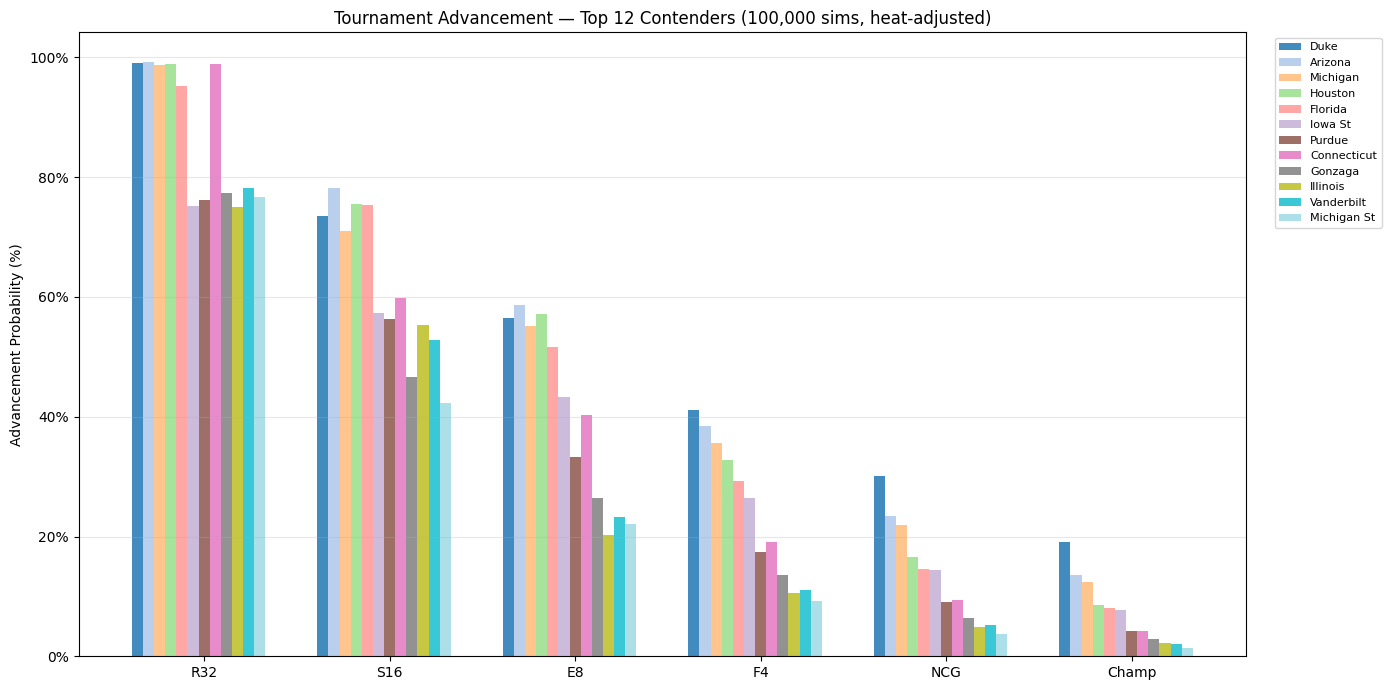

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ──────────────────────────────────────────────────────────────────────
#  Cinderella Runs — teams seeded 10+ that make deep runs
# ──────────────────────────────────────────────────────────────────────

cinderella_data = []
for tid, rc in team_round_counts.items():
    seed_str = tid_to_seed.get(tid, "?")
    seed_num = int(seed_str[1:3]) if seed_str != "?" else 0
    if seed_num >= 10:
        s16_pct = rc.get(3, 0) / N_SIMS * 100
        e8_pct = rc.get(4, 0) / N_SIMS * 100
        if s16_pct > 1.0:  # At least 1% chance of S16
            cinderella_data.append({
                "name": tid_to_name.get(tid, str(tid)),
                "seed": seed_str,
                "seed_num": seed_num,
                "tid": tid,
                "R32": rc.get(1, 0) / N_SIMS * 100,
                "S16": s16_pct,
                "E8": e8_pct,
                "F4": rc.get(5, 0) / N_SIMS * 100,
            })

cinderella_data.sort(key=lambda x: -x["S16"])

print("🏀 Cinderella Watch — Seeds 10+ with Sweet 16 Potential\n")
print(f"{'Team':<25} {'Seed':<6} {'R32%':>7} {'S16%':>7} {'E8%':>7} {'F4%':>7}")
print("─" * 60)
for c in cinderella_data[:12]:
    print(f"{c['name']:<25} {c['seed']:<6} {c['R32']:>6.1f}% {c['S16']:>6.1f}% {c['E8']:>6.1f}% {c['F4']:>6.1f}%")

# ──────────────────────────────────────────────────────────────────────
#  Advancement Probability Chart — top 12 teams
# ──────────────────────────────────────────────────────────────────────

top_12_tids = [tid for tid, _ in champ_sorted[:12]]
rounds_to_plot = [1, 2, 3, 4, 5, 6]  # R32 through Champ

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(rounds_to_plot))
width = 0.06
n_teams = len(top_12_tids)

colors = plt.cm.tab20(np.linspace(0, 1, n_teams))

for i, tid in enumerate(top_12_tids):
    rc = team_round_counts.get(tid, {})
    vals = [rc.get(r, 0) / N_SIMS * 100 for r in rounds_to_plot]
    offset = (i - n_teams / 2) * width
    bars = ax.bar(x + offset, vals, width, label=tid_to_name.get(tid, str(tid)),
                  color=colors[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(["R32", "S16", "E8", "F4", "NCG", "Champ"])
ax.set_ylabel("Advancement Probability (%)")
ax.set_title(f"Tournament Advancement — Top 12 Contenders ({N_SIMS:,} sims, heat-adjusted)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Heat Variable Statistics Across Simulations

This section shows how the in-simulation heat variables evolve for all tournament teams. Heat accumulates during a team's tournament run based on upset wins and decays each round. Teams with high ending heat are the ones that consistently overperform their seed expectations across the simulation ensemble.

  PRE-TOURNAMENT HEAT SCORES (entering the tournament)
Team                   Seed    Heat-1g  Heat-3g  Heat-5g     ELO
-------------------------------------------------------------------------------------
Prairie View           X16b     +20.74   +12.02   +14.39    1472
Tennessee St           Y15       +6.02   +17.34   +14.14    1667
UMBC                   Y16b      +5.05   +10.17    +8.74    1647
Wisconsin              Z05       +8.30    +4.72    +8.72    1751
Howard                 Y16a      +1.75    +2.27    +8.48    1600
Iowa St                Y02      +19.57   +20.29    +8.43    1801
UCLA                   W07      +10.23    +8.92    +8.13    1716
Idaho                  X15      +13.19   +11.77    +7.94    1556
Florida                X01       -6.26    +1.28    +6.03    1881
TCU                    W09       -1.48    +8.48    +5.89    1690
Penn                   X14       +4.39    +6.51    +5.58    1612
Ohio St                W08       +1.20    +7.87    +5.18    1702
Houston       

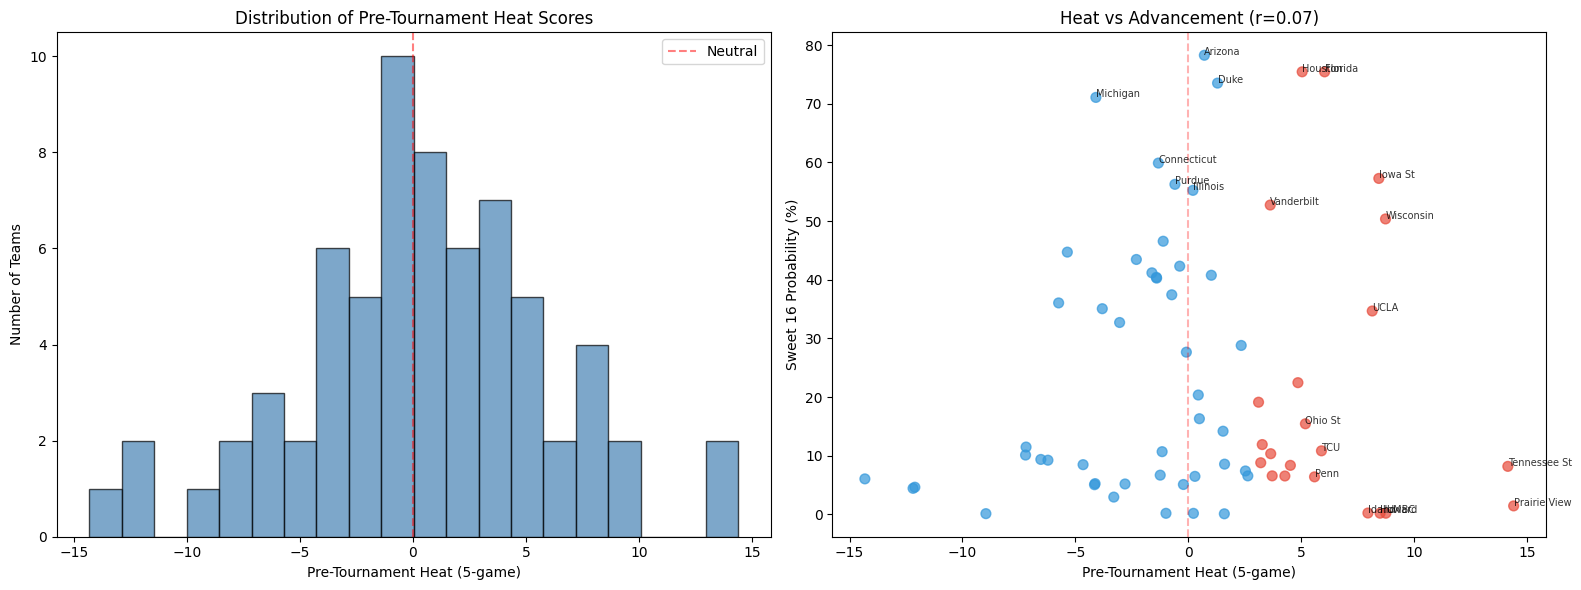

In [9]:
# ──────────────────────────────────────────────────────────────────────
#  Heat Statistics: Pre-tournament heat + simulation heat accumulation
# ──────────────────────────────────────────────────────────────────────

# 1. Pre-tournament heat for all 68 teams
print("=" * 85)
print("  PRE-TOURNAMENT HEAT SCORES (entering the tournament)")
print("=" * 85)
print(f"{'Team':<22} {'Seed':<6} {'Heat-1g':>8} {'Heat-3g':>8} {'Heat-5g':>8} {'ELO':>7}")
print("-" * 85)

heat_rows = []
for row in m_2026.join(
    seeds_2026.select(pl.col("TeamID").cast(pl.Int64).alias("team_id"), pl.col("Seed")),
    on="team_id", how="inner"
).sort("pre_tourney_heat_5g", descending=True).iter_rows(named=True):
    tid = row["team_id"]
    name = tid_to_name.get(tid, str(tid))
    h1 = row.get("pre_tourney_heat_1g") or 0.0
    h3 = row.get("pre_tourney_heat_3g") or 0.0
    h5 = row.get("pre_tourney_heat_5g") or 0.0
    elo = row.get("season_end_elo") or 1500
    heat_rows.append({"tid": tid, "name": name, "seed": row["Seed"],
                       "h1": h1, "h3": h3, "h5": h5, "elo": elo})
    print(f"{name:<22} {row['Seed']:<6} {h1:>+8.2f} {h3:>+8.2f} {h5:>+8.2f} {elo:>7.0f}")

# 2. Simulation heat analysis — average ending heat by how far teams advance
# We can compute average heat at each slot for teams that made it there
print(f"\n{'=' * 85}")
print("  SIMULATION HEAT ACCUMULATION BY ROUND (avg heat of teams reaching each round)")
print("=" * 85)

# For each team, compute their average heat when they win a game at each round
# We use slot_winner_counts and the heat_at array (still in memory from the sim)
# Reconstruct per-round average heat from the heat_at array

# Map slot -> array index
# For each slot, get the output index and compute mean heat of the winning team
round_avg_heat = {}
for rnd in range(1, 7):
    heats = []
    for sl_info in slots:
        sl_name = sl_info["slot"]
        if sl_name[0] == "R" and sl_name[1].isdigit() and int(sl_name[1]) == rnd:
            oi = key_to_idx[sl_name]
            # Get heat values where a team exists (non-zero)
            valid = heat_at[:, oi][team_at[:, oi] > 0]
            if len(valid) > 0:
                heats.extend(valid.tolist())
    if heats:
        round_avg_heat[rnd] = {
            "mean": np.mean(heats),
            "median": np.median(heats),
            "std": np.std(heats),
            "max": np.max(heats),
            "p90": np.percentile(heats, 90),
        }

round_name_map = {1: "R32", 2: "S16", 3: "E8", 4: "F4", 5: "NCG", 6: "Champ"}
print(f"{'Round':<8} {'Mean Heat':>10} {'Median':>10} {'Std Dev':>10} {'P90':>10} {'Max':>10}")
print("-" * 60)
for rnd in range(1, 7):
    if rnd in round_avg_heat:
        s = round_avg_heat[rnd]
        print(f"{round_name_map[rnd]:<8} {s['mean']:>10.2f} {s['median']:>10.2f} "
              f"{s['std']:>10.2f} {s['p90']:>10.2f} {s['max']:>10.2f}")

# 3. Per-team heat analysis — initial heat vs simulation advancement
print(f"\n{'=' * 85}")
print("  HEAT vs ADVANCEMENT — Do hot teams go further?")
print("=" * 85)
print(f"{'Team':<22} {'Seed':<6} {'Init H5':>8} {'R32%':>7} {'S16%':>7} {'E8%':>7} {'F4%':>7} {'Champ%':>7}")
print("-" * 85)

# Sort by initial heat, show all 68
for hr in heat_rows:
    tid = hr["tid"]
    rc = team_round_counts.get(tid, {})
    r32 = rc.get(1, 0) / N_SIMS * 100
    s16 = rc.get(2, 0) / N_SIMS * 100
    e8 = rc.get(3, 0) / N_SIMS * 100
    f4 = rc.get(4, 0) / N_SIMS * 100
    ch = champion_counts.get(tid, 0) / N_SIMS * 100
    print(f"{hr['name']:<22} {hr['seed']:<6} {hr['h5']:>+8.2f} "
          f"{r32:>6.1f}% {s16:>6.1f}% {e8:>6.1f}% {f4:>6.1f}% {ch:>6.2f}%")

# 4. Heat correlation
import scipy.stats as stats
h5_vals = [hr["h5"] for hr in heat_rows]
adv_vals = [team_round_counts.get(hr["tid"], {}).get(2, 0) / N_SIMS * 100 for hr in heat_rows]
corr, pval = stats.pearsonr(h5_vals, adv_vals)
print(f"\nCorrelation (pre-tourney heat_5g vs S16%): r={corr:.3f}, p={pval:.4f}")

# 5. Heat chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Pre-tournament heat distribution
h5_arr = np.array(h5_vals)
ax1.hist(h5_arr, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
ax1.set_xlabel("Pre-Tournament Heat (5-game)")
ax1.set_ylabel("Number of Teams")
ax1.set_title("Distribution of Pre-Tournament Heat Scores")
ax1.axvline(0, color="red", linestyle="--", alpha=0.5, label="Neutral")
ax1.legend()

# Right: Heat vs S16 advancement
colors_scatter = ["#e74c3c" if hr["h5"] > 3 else "#3498db" for hr in heat_rows]
ax2.scatter(h5_vals, adv_vals, c=colors_scatter, alpha=0.7, s=50)
for hr in heat_rows:
    if hr["h5"] > 5 or team_round_counts.get(hr["tid"], {}).get(2, 0) / N_SIMS > 0.5:
        ax2.annotate(hr["name"], (hr["h5"], team_round_counts.get(hr["tid"], {}).get(2, 0) / N_SIMS * 100),
                     fontsize=7, alpha=0.8, ha="left")
ax2.set_xlabel("Pre-Tournament Heat (5-game)")
ax2.set_ylabel("Sweet 16 Probability (%)")
ax2.set_title(f"Heat vs Advancement (r={corr:.2f})")
ax2.axvline(0, color="red", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 🏆 Bracket Selection Strategies

Three approaches to turn simulation results into a printable bracket:

| Strategy | Philosophy | Best For |
|----------|-----------|----------|
| **Modal Bracket** | Pick the most frequent winner of each slot across all sims | Maximizing expected correct picks — your "safest" bracket |
| **Chalk+ Bracket** | Favor expected seeds, but override when the model gives underdogs >40% | Office pools where you need a few upsets but can't go crazy |
| **Upset Special** | Find games where heat-adjusted win% diverges most from seed expectation, and lean into those upsets | Pools with many entries where you need differentiation |

In [10]:
# ──────────────────────────────────────────────────────────────────────
#  Strategy 1: Modal Bracket — most frequent winner of each slot
# ──────────────────────────────────────────────────────────────────────

def build_modal_bracket() -> dict[str, tuple[int, str, float]]:
    """Returns {slot: (tid, team_name, win_pct)} picking the most frequent winner."""
    bracket = {}
    for slot_info in slots:
        slot_name = slot_info["slot"]
        winners = slot_winner_counts.get(slot_name, {})
        if not winners:
            continue
        best_tid = max(winners, key=lambda t: winners[t])
        pct = winners[best_tid] / N_SIMS * 100
        bracket[slot_name] = (best_tid, tid_to_name.get(best_tid, str(best_tid)), pct)
    return bracket


# ──────────────────────────────────────────────────────────────────────
#  Strategy 2: Chalk+ — favor seeds, override on strong upsets (>40%)
# ──────────────────────────────────────────────────────────────────────

def build_chalk_plus_bracket() -> dict[str, tuple[int, str, float]]:
    """Favor the higher-seeded team unless the lower seed wins >40% of sims."""
    bracket = {}
    advancing: dict[str, int] = dict(seed_to_team)  # seed -> tid

    for slot_info in slots:
        slot_name = slot_info["slot"]
        strong_key = slot_info["strong"]
        weak_key = slot_info["weak"]

        tid_strong = advancing.get(strong_key)
        tid_weak = advancing.get(weak_key)
        if tid_strong is None or tid_weak is None:
            continue

        winners = slot_winner_counts.get(slot_name, {})
        total = sum(winners.values()) or 1
        weak_pct = winners.get(tid_weak, 0) / total

        # In "Chalk+" we pick the strong seed UNLESS the weak side wins >=40%
        if weak_pct >= 0.40:
            pick = tid_weak
            pct = weak_pct * 100
        else:
            pick = tid_strong
            pct = winners.get(tid_strong, 0) / total * 100

        bracket[slot_name] = (pick, tid_to_name.get(pick, str(pick)), pct)
        advancing[slot_name] = pick

    return bracket


# Build Chalk+ bracket (final bracket strategy)
chalk_bracket = build_chalk_plus_bracket()

# ──────────────────────────────────────────────────────────────────────
#  Full 64-Team Chalk+ Bracket
# ──────────────────────────────────────────────────────────────────────

ROUND_LABELS = {1: "Round of 64", 2: "Round of 32", 3: "Sweet 16",
                4: "Elite Eight", 5: "Final Four", 6: "Championship"}

slot_matchup = {s["slot"]: (s["strong"], s["weak"]) for s in slots}

def seed_label(key: str) -> str:
    if key in seed_to_name:
        num = key[1:].lstrip("0") or "0"
        return f"({num}) {seed_to_name[key]}"
    if key in chalk_bracket:
        _, name, _ = chalk_bracket[key]
        return name
    return key

def fmt_pick(slot: str) -> str:
    if slot not in chalk_bracket:
        return "---"
    tid, name, pct = chalk_bracket[slot]
    sd = tid_to_seed.get(tid, "?")
    num = sd[1:].lstrip("0") if sd != "?" else "?"
    return f"({num}) {name} [{pct:.0f}%]"


for region_code, region_name in [("W", "WEST"), ("X", "EAST"), ("Y", "SOUTH"), ("Z", "MIDWEST")]:
    print(f"\n{'=' * 80}")
    print(f"  {region_name} REGION")
    print(f"{'=' * 80}")

    for rnd in [1, 2, 3, 4]:
        prefix = f"R{rnd}{region_code}"
        round_slots = sorted([s["slot"] for s in slots
                              if s["slot"].startswith(prefix)])
        if not round_slots:
            continue

        print(f"\n  -- {ROUND_LABELS[rnd]} {'-' * (60 - len(ROUND_LABELS[rnd]))}")
        for sl in round_slots:
            strong_key, weak_key = slot_matchup[sl]
            strong_lbl = seed_label(strong_key)
            weak_lbl = seed_label(weak_key)
            winner_str = fmt_pick(sl)

            if rnd == 1:
                print(f"    {strong_lbl:<28} vs {weak_lbl:<28}")
                print(f"      -> Winner: {winner_str}")
            else:
                print(f"    {winner_str}")

# -- Final Four + Championship --
print(f"\n{'=' * 80}")
print(f"  FINAL FOUR & CHAMPIONSHIP")
print(f"{'=' * 80}")

for sl in ["R5WX", "R5YZ"]:
    if sl in chalk_bracket and sl in slot_matchup:
        strong_key, weak_key = slot_matchup[sl]
        s_lbl = seed_label(strong_key) if strong_key in seed_to_name else fmt_pick(strong_key)
        w_lbl = seed_label(weak_key) if weak_key in seed_to_name else fmt_pick(weak_key)
        sf_winner = fmt_pick(sl)
        semi = "West/East" if sl == "R5WX" else "South/Midwest"
        print(f"\n  -- Final Four: {semi} {'-' * 40}")
        print(f"    {s_lbl}  vs  {w_lbl}")
        print(f"      -> Winner: {sf_winner}")

if "R6CH" in chalk_bracket:
    print(f"\n  -- Championship {'-' * 50}")
    strong_key, weak_key = slot_matchup["R6CH"]
    s_lbl = fmt_pick(strong_key)
    w_lbl = fmt_pick(weak_key)
    champ = fmt_pick("R6CH")
    print(f"    {s_lbl}  vs  {w_lbl}")
    print(f"\n  CHAMPION: {champ}")

# -- Summary stats --
print(f"\n{'=' * 80}")
print(f"  CHALK+ BRACKET SUMMARY  (based on {N_SIMS:,} heat-adjusted simulations)")
print(f"{'=' * 80}")

n_upsets = 0
for sl, (tid, name, pct) in chalk_bracket.items():
    if not sl.startswith("R1"):
        continue
    strong_key = slot_matchup[sl][0]
    if strong_key in seed_to_team:
        strong_tid = seed_to_team[strong_key]
        if tid != strong_tid:
            n_upsets += 1
            sd = tid_to_seed.get(tid, "?")
            num = sd[1:].lstrip("0") if sd != "?" else "?"
            opp_sd = strong_key
            opp_num = opp_sd[1:].lstrip("0") if opp_sd != "?" else "?"
            print(f"  R1 Upset: ({num}) {name} over ({opp_num}) {seed_to_name.get(strong_key, '?')}")

print(f"\n  First-round upsets picked: {n_upsets}")
print(f"  Champion: {chalk_bracket.get('R6CH', (0, '?', 0))[1]}")


  WEST REGION

  -- Round of 64 -------------------------------------------------
    (1) Duke                     vs (16) Siena                  
      -> Winner: (1) Duke [99%]
    (2) Connecticut              vs (15) Furman                 
      -> Winner: (2) Connecticut [99%]
    (3) Michigan St              vs (14) N Dakota St            
      -> Winner: (3) Michigan St [77%]
    (4) Kansas                   vs (13) Cal Baptist            
      -> Winner: (4) Kansas [72%]
    (5) St John's                vs (12) Northern Iowa          
      -> Winner: (5) St John's [83%]
    (6) Louisville               vs (11) South Florida          
      -> Winner: (6) Louisville [73%]
    (7) UCLA                     vs (10) UCF                    
      -> Winner: (7) UCLA [78%]
    (8) Ohio St                  vs (9) TCU                     
      -> Winner: (9) TCU [41%]

  -- Round of 32 -------------------------------------------------
    (1) Duke [74%]
    (2) Connecticut [60%]
  

In [11]:
# ──────────────────────────────────────────────────────────────────────
#  Interactive Bracket Builder (ipywidgets)
#  Click a team to pick them as the winner. Downstream matchups update
#  automatically with new head-to-head probabilities.
# ──────────────────────────────────────────────────────────────────────

import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Bracket state ─────────────────────────────────────────────────────
# advancing[key] = tid — tracks who occupies each seed/slot position
_advancing: dict[str, int | None] = {s: tid for s, tid in seed_to_team.items()}

# picks[slot] = tid — which team the user picked to win each slot
_picks: dict[str, int | None] = {}

# Build routing: for each key (seed or slot), which downstream slot consumes it?
_feeds_into: dict[str, str] = {}       # key -> downstream slot name
_feeds_side: dict[str, str] = {}       # key -> "strong" or "weak"
for _s in slots:
    _feeds_into[_s["strong"]] = _s["slot"]
    _feeds_side[_s["strong"]] = "strong"
    _feeds_into[_s["weak"]] = _s["slot"]
    _feeds_side[_s["weak"]] = "weak"

# Collect all downstream slots from a given slot (for clearing)
def _downstream(slot_name: str) -> list[str]:
    """Return list of all slots downstream of this one, in bracket order."""
    result = []
    cur = slot_name
    while cur in _feeds_into:
        nxt = _feeds_into[cur]
        result.append(nxt)
        cur = nxt
    return result


# ── Probability helper ────────────────────────────────────────────────
def _h2h(tid_a: int, tid_b: int) -> float:
    """Return P(tid_a wins) from submission model."""
    low, high = min(tid_a, tid_b), max(tid_a, tid_b)
    p_low = prob_lookup.get((low, high), 0.5)
    return p_low if tid_a == low else 1.0 - p_low


def _team_label(tid: int | None) -> str:
    if tid is None:
        return "TBD"
    sd = tid_to_seed.get(tid, "?")
    num = sd[1:].lstrip("0") if sd != "?" else "?"
    name = tid_to_name.get(tid, str(tid))
    return f"({num}) {name}"


# ── Widget storage ────────────────────────────────────────────────────
_slot_widgets: dict[str, dict] = {}  # slot -> {"box": HBox, "btn_s": Button, "btn_w": Button}
_summary_out = widgets.Output()


def _make_btn(label: str, is_picked: bool, disabled: bool = False) -> widgets.Button:
    btn = widgets.Button(
        description=label,
        layout=widgets.Layout(width="200px", height="42px"),
        disabled=disabled,
    )
    btn.style.font_weight = "bold"
    if disabled:
        btn.style.button_color = "#e0e0e0"
        btn.style.text_color = "#999999" if hasattr(btn.style, "text_color") else None
    elif is_picked:
        btn.style.button_color = "#4CAF50"
    else:
        btn.style.button_color = "#f0f0f0"
    return btn


def _refresh_slot(slot_name: str):
    """Refresh the widget display for a single slot."""
    if slot_name not in _slot_widgets:
        return

    sw = _slot_widgets[slot_name]
    s_info = sw["slot_info"]
    strong_key = s_info["strong"]
    weak_key = s_info["weak"]

    tid_s = _advancing.get(strong_key)
    tid_w = _advancing.get(weak_key)
    picked = _picks.get(slot_name)

    # Build labels with H2H probabilities
    if tid_s is not None and tid_w is not None:
        p_s = _h2h(tid_s, tid_w)
        p_w = 1.0 - p_s
        lbl_s = f"{_team_label(tid_s)}  {p_s:.0%}"
        lbl_w = f"{_team_label(tid_w)}  {p_w:.0%}"
        disabled_s = False
        disabled_w = False
    elif tid_s is not None:
        lbl_s = _team_label(tid_s)
        lbl_w = "TBD"
        disabled_s = True
        disabled_w = True
    elif tid_w is not None:
        lbl_s = "TBD"
        lbl_w = _team_label(tid_w)
        disabled_s = True
        disabled_w = True
    else:
        lbl_s = "TBD"
        lbl_w = "TBD"
        disabled_s = True
        disabled_w = True

    # Update strong-side button
    btn_s = sw["btn_s"]
    btn_s.description = lbl_s
    btn_s.disabled = disabled_s
    if disabled_s:
        btn_s.style.button_color = "#e0e0e0"
    elif picked == tid_s and tid_s is not None:
        btn_s.style.button_color = "#4CAF50"
    else:
        btn_s.style.button_color = "#f0f0f0"

    # Update weak-side button
    btn_w = sw["btn_w"]
    btn_w.description = lbl_w
    btn_w.disabled = disabled_w
    if disabled_w:
        btn_w.style.button_color = "#e0e0e0"
    elif picked == tid_w and tid_w is not None:
        btn_w.style.button_color = "#4CAF50"
    else:
        btn_w.style.button_color = "#f0f0f0"


def _on_pick(slot_name: str, side: str):
    """Handle clicking a team button."""
    s_info = None
    for _s in slots:
        if _s["slot"] == slot_name:
            s_info = _s
            break
    if s_info is None:
        return

    key = s_info["strong"] if side == "strong" else s_info["weak"]
    tid = _advancing.get(key)
    if tid is None:
        return

    # Record pick
    _picks[slot_name] = tid
    _advancing[slot_name] = tid

    # Clear all downstream picks
    for ds in _downstream(slot_name):
        _picks.pop(ds, None)
        _advancing.pop(ds, None)

    # Refresh this slot and all downstream
    _refresh_slot(slot_name)
    for ds in _downstream(slot_name):
        _refresh_slot(ds)

    # Update summary
    _update_summary()


def _update_summary():
    with _summary_out:
        clear_output(wait=True)
        print("━" * 60)
        print("  YOUR BRACKET PICKS")
        print("━" * 60)

        # Final Four
        f4_slots = {"R5WX": "West/East", "R5YZ": "South/Midwest"}
        for sl, label in f4_slots.items():
            if sl in _picks and _picks[sl] is not None:
                print(f"  {label} Winner: {_team_label(_picks[sl])}")
            else:
                print(f"  {label} Winner: ---")

        if "R6CH" in _picks and _picks["R6CH"] is not None:
            champ_tid = _picks["R6CH"]
            print(f"\n  🏆 CHAMPION: {_team_label(champ_tid)}")
        else:
            print(f"\n  🏆 CHAMPION: ---")

        # Count picks
        total_picked = sum(1 for v in _picks.values() if v is not None)
        total_games = len(slots)
        print(f"\n  Games filled: {total_picked}/{total_games}")
        print("━" * 60)


# ── Build all matchup widgets ─────────────────────────────────────────
for _s in slots:
    _sn = _s["slot"]
    btn_s = _make_btn("TBD", False, True)
    btn_w = _make_btn("TBD", False, True)

    # Wire click handlers
    slot_name_capture = _sn
    btn_s.on_click(lambda _b, sn=slot_name_capture: _on_pick(sn, "strong"))
    btn_w.on_click(lambda _b, sn=slot_name_capture: _on_pick(sn, "weak"))

    vs_label = widgets.HTML(value="<b style='margin: 0 4px'>vs</b>")
    box = widgets.HBox([btn_s, vs_label, btn_w])

    _slot_widgets[_sn] = {
        "box": box,
        "btn_s": btn_s,
        "btn_w": btn_w,
        "slot_info": _s,
    }


# ── Pre-populate from Chalk+ bracket ─────────────────────────────────
# First resolve play-in games silently
for _s in slots:
    _sn = _s["slot"]
    if _sn.startswith("R"):
        continue  # skip round games, only auto-pick play-ins
    if _sn in chalk_bracket:
        pick_tid = chalk_bracket[_sn][0]
        _picks[_sn] = pick_tid
        _advancing[_sn] = pick_tid

# Now pre-populate all round games from chalk bracket
for _s in slots:
    _sn = _s["slot"]
    if not _sn.startswith("R"):
        continue
    if _sn in chalk_bracket:
        pick_tid = chalk_bracket[_sn][0]
        _picks[_sn] = pick_tid
        _advancing[_sn] = pick_tid

# Refresh every widget now that state is populated
for _sn in _slot_widgets:
    _refresh_slot(_sn)


# ── Layout by region ──────────────────────────────────────────────────
_region_labels = {"W": "🏀 WEST", "X": "🏀 EAST", "Y": "🏀 SOUTH", "Z": "🏀 MIDWEST"}
_round_labels = {1: "Round of 64", 2: "Round of 32", 3: "Sweet 16", 4: "Elite Eight"}

_region_vboxes = []
for _rc in ["W", "X", "Y", "Z"]:
    region_children = [widgets.HTML(f"<h3 style='margin: 4px 0'>{_region_labels[_rc]}</h3>")]
    for _rnd in [1, 2, 3, 4]:
        prefix = f"R{_rnd}{_rc}"
        rnd_slots = sorted([s["slot"] for s in slots if s["slot"].startswith(prefix)])
        if not rnd_slots:
            continue
        region_children.append(widgets.HTML(
            f"<b style='color: #555; font-size: 11px'>{_round_labels[_rnd]}</b>"
        ))
        for _sn in rnd_slots:
            region_children.append(_slot_widgets[_sn]["box"])
    _region_vboxes.append(widgets.VBox(region_children,
        layout=widgets.Layout(border="1px solid #ddd", padding="8px", margin="4px",
                              width="460px")))

# Final Four / Championship column
_ff_children = [widgets.HTML("<h3 style='margin: 4px 0'>🏆 FINAL FOUR</h3>")]
for _sl, _lbl in [("R5WX", "West vs East"), ("R5YZ", "South vs Midwest")]:
    if _sl in _slot_widgets:
        _ff_children.append(widgets.HTML(f"<b style='color: #555; font-size: 11px'>{_lbl}</b>"))
        _ff_children.append(_slot_widgets[_sl]["box"])

_ff_children.append(widgets.HTML("<h3 style='margin: 8px 0 4px'>🏆 CHAMPIONSHIP</h3>"))
if "R6CH" in _slot_widgets:
    _ff_children.append(_slot_widgets["R6CH"]["box"])

_ff_children.append(widgets.HTML("<hr>"))
_ff_children.append(_summary_out)

_ff_box = widgets.VBox(_ff_children,
    layout=widgets.Layout(border="2px solid #333", padding="8px", margin="4px",
                          width="460px", background_color="#fafafa" if False else None))

# Arrange: two regions on left, center column, two regions on right
_left_col = widgets.VBox([_region_vboxes[0], _region_vboxes[2]])   # West, South
_right_col = widgets.VBox([_region_vboxes[1], _region_vboxes[3]])  # East, Midwest

_bracket_ui = widgets.HBox(
    [_left_col, _ff_box, _right_col],
    layout=widgets.Layout(justify_content="center"),
)

# Initialize summary
_update_summary()

print("🏀 Interactive Bracket Builder — Click any team to pick them as the winner")
print("   Pre-populated with Chalk+ picks. Override any game by clicking the other team.\n")
display(_bracket_ui)

🏀 Interactive Bracket Builder — Click any team to pick them as the winner
   Pre-populated with Chalk+ picks. Override any game by clicking the other team.



## Adjusted Submission: Iowa St Title Run

Create a modified submission CSV that:
- Keeps all model probabilities as-is (Brier-optimized) for games not involving the target path
- Boosts the 4 Final Four teams (Duke, Florida, Iowa St, Arizona) in their pairwise matchups against all other tournament teams
- Sets specific probabilities for the F4 matchups: Florida over Duke, Iowa St over Arizona, Iowa St over Florida (champion)

The boost uses a logit-space shift so it stays well-calibrated near the boundaries.

In [12]:
# ──────────────────────────────────────────────────────────────────────
#  Build adjusted submission: ISU title, F4 = Duke/Florida/Arizona/ISU
#  Championship: ISU beats Florida
# ──────────────────────────────────────────────────────────────────────

# Target teams
DUKE = 1181      # W01 - West
FLORIDA = 1196   # X01 - East
IOWA_ST = 1235   # Y02 - South
ARIZONA = 1112   # Z01 - Midwest

F4_TIDS = {DUKE, FLORIDA, IOWA_ST, ARIZONA}

# All 68 tournament team IDs
TOURNEY_TIDS = set(seed_to_team.values())

# Load baseline submission
adj_sub = submission.clone()

def logit(p):
    p = np.clip(p, 0.005, 0.995)
    return np.log(p / (1.0 - p))

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# Strategy:
# 1. For matchups between an F4 team and a non-F4 tournament team:
#    apply a moderate logit boost (+0.5) favoring the F4 team
# 2. For specific F4 head-to-head matchups, set explicit probabilities:
#    - Duke vs Florida: P(Duke wins) = 0.40 (Florida favored)
#    - Duke vs Iowa St: P(Duke wins) = 0.42 (ISU slightly favored)
#    - Duke vs Arizona: P(Duke wins) = 0.55 (Duke slightly favored, they don't meet)
#    - Florida vs Iowa St: P(Florida wins) = 0.42 (ISU wins championship)
#    - Florida vs Arizona: P(Florida wins) = 0.55 (Florida favored)
#    - Iowa St vs Arizona: P(Iowa St wins - but lower ID wins format) = depends on ID order
#    Note: submission format is P(lower_ID team wins) where pair is (low, high)

# Explicit F4 matchup overrides: key=(low_tid, high_tid), value=P(low wins)
# Duke=1181, Arizona=1112, Florida=1196, Iowa St=1235
# Pairs sorted: (1112,1181)=Arizona/Duke, (1112,1196)=Arizona/Florida,
#               (1112,1235)=Arizona/ISU, (1181,1196)=Duke/Florida,
#               (1181,1235)=Duke/ISU, (1196,1235)=Florida/ISU
F4_OVERRIDES = {
    (1112, 1181): 0.45,  # Arizona vs Duke -> P(Arizona wins)=0.45  (irrelevant path, keep balanced)
    (1112, 1196): 0.45,  # Arizona vs Florida -> P(Arizona wins)=0.45
    (1112, 1235): 0.48,  # Arizona vs Iowa St -> P(Arizona wins)=0.48 (ISU wins R5YZ)
    (1181, 1196): 0.48,  # Duke vs Florida -> P(Duke wins)=0.48 (Florida wins R5WX)
    (1181, 1235): 0.45,  # Duke vs Iowa St -> P(Duke wins)=0.45 (ISU stronger overall)
    (1196, 1235): 0.48,  # Florida vs Iowa St -> P(Florida wins)=0.48 (ISU wins title)
}

BOOST_LOGIT = 0.5  # Moderate logit-space boost for F4 teams vs non-F4 opponents

n_boosted = 0
n_overridden = 0
adjustments = []

for row in adj_sub.iter_rows(named=True):
    id_str = row["ID"]
    parts = id_str.split("_")
    season = int(parts[0])
    low_tid = int(parts[1])
    high_tid = int(parts[2])
    orig_p = float(row["Pred"])

    # Only adjust Men's 2026 tournament matchups
    if season != 2026 or low_tid >= 2000:
        continue

    # Both must be tournament teams for any adjustment
    if low_tid not in TOURNEY_TIDS or high_tid not in TOURNEY_TIDS:
        continue

    pair = (low_tid, high_tid)

    # Check if this is an F4 head-to-head override
    if pair in F4_OVERRIDES:
        new_p = F4_OVERRIDES[pair]
        adjustments.append((id_str, orig_p, new_p, "F4 override"))
        n_overridden += 1
        continue

    # Check if one team is F4 and the other is not
    low_is_f4 = low_tid in F4_TIDS
    high_is_f4 = high_tid in F4_TIDS

    if low_is_f4 and not high_is_f4:
        # Boost P(low wins)
        new_p = sigmoid(logit(orig_p) + BOOST_LOGIT)
        adjustments.append((id_str, orig_p, new_p, f"boost {tid_to_name.get(low_tid)}"))
        n_boosted += 1
    elif high_is_f4 and not low_is_f4:
        # Boost P(high wins) = reduce P(low wins)
        new_p = sigmoid(logit(orig_p) - BOOST_LOGIT)
        adjustments.append((id_str, orig_p, new_p, f"boost {tid_to_name.get(high_tid)}"))
        n_boosted += 1

# Apply adjustments to the dataframe
if adjustments:
    id_to_new_p = {a[0]: a[2] for a in adjustments}
    adj_sub = adj_sub.with_columns(
        pl.when(pl.col("ID").is_in(list(id_to_new_p.keys())))
        .then(
            pl.col("ID").replace_strict(id_to_new_p, default=pl.col("Pred"))
        )
        .otherwise(pl.col("Pred"))
        .alias("Pred")
    )

# Save adjusted submission
out_path = BASE / "submission_isu_title.csv"
adj_sub.write_csv(out_path)

print(f"Adjusted submission saved to: {out_path}")
print(f"  F4 overrides: {n_overridden}")
print(f"  F4 boosts:    {n_boosted}")
print(f"  Total rows:   {adj_sub.height:,}")
print(f"  Pred range:   [{adj_sub['Pred'].min():.4f}, {adj_sub['Pred'].max():.4f}]")

print(f"\nF4 Head-to-Head Overrides:")
for a in adjustments:
    if a[3] == "F4 override":
        parts = a[0].split("_")
        low_name = tid_to_name.get(int(parts[1]), "?")
        high_name = tid_to_name.get(int(parts[2]), "?")
        print(f"  {low_name} vs {high_name}: {a[1]:.3f} -> {a[2]:.3f}  P({low_name})={a[2]:.0%}")

print(f"\nSample F4 boosts (largest shifts):")
boost_adjustments = [(a[0], a[1], a[2], a[3], abs(a[2]-a[1])) for a in adjustments if a[3] != "F4 override"]
boost_adjustments.sort(key=lambda x: -x[4])
for a in boost_adjustments[:10]:
    parts = a[0].split("_")
    low_name = tid_to_name.get(int(parts[1]), "?")
    high_name = tid_to_name.get(int(parts[2]), "?")
    direction = "+" if a[2] > a[1] else "-"
    print(f"  {low_name} vs {high_name}: {a[1]:.3f} -> {a[2]:.3f} ({direction}{a[4]:.3f})  [{a[3]}]")

Adjusted submission saved to: C:\Users\sdiehl\Desktop\seandiehlprojects\mm26\artifacts\latest\submission_isu_title.csv
  F4 overrides: 6
  F4 boosts:    256
  Total rows:   132,133
  Pred range:   [0.0061, 0.9939]

F4 Head-to-Head Overrides:
  Arizona vs Duke: 0.438 -> 0.450  P(Arizona)=45%
  Arizona vs Florida: 0.594 -> 0.450  P(Arizona)=45%
  Arizona vs Iowa St: 0.594 -> 0.480  P(Arizona)=48%
  Duke vs Florida: 0.737 -> 0.480  P(Duke)=48%
  Duke vs Iowa St: 0.594 -> 0.450  P(Duke)=45%
  Florida vs Iowa St: 0.500 -> 0.480  P(Florida)=48%

Sample F4 boosts (largest shifts):
  Arizona vs Michigan: 0.500 -> 0.622 (+0.122)  [boost Arizona]
  Florida vs Houston: 0.500 -> 0.622 (+0.122)  [boost Florida]
  Florida vs Michigan: 0.500 -> 0.622 (+0.122)  [boost Florida]
  Florida vs Purdue: 0.500 -> 0.622 (+0.122)  [boost Florida]
  Houston vs Iowa St: 0.500 -> 0.378 (-0.122)  [boost Iowa St]
  Illinois vs Iowa St: 0.500 -> 0.378 (-0.122)  [boost Iowa St]
  Iowa St vs Michigan: 0.500 -> 0.622 (

---

## Submission Ready Checks

Run the cell below to verify the current `artifacts/latest/submission.csv` is valid for upload and to preview confidence tails.

In [13]:
# Submission contract checks + confidence tails
sub = pl.read_csv(BASE / "submission.csv")

bad_id = sub.filter(~pl.col("ID").str.contains(r"^\d{4}_\d+_\d+$")).height
null_pred = sub.filter(pl.col("Pred").is_null()).height
out_of_range = sub.filter((pl.col("Pred") < 0.0) | (pl.col("Pred") > 1.0)).height

print("=== SUBMISSION CHECKS ===")
print(f"Rows          : {sub.height:,}")
print(f"Malformed IDs : {bad_id}")
print(f"Null Pred     : {null_pred}")
print(f"Out of range  : {out_of_range}")
print(f"Pred range    : [{sub['Pred'].min():.4f}, {sub['Pred'].max():.4f}]")
print(f"Pred mean     : {sub['Pred'].mean():.4f}")

print("\nMost confident TeamLow picks:")
print(sub.sort("Pred", descending=True).head(10))

print("\nMost confident TeamHigh picks:")
print(sub.sort("Pred", descending=False).head(10))

=== SUBMISSION CHECKS ===
Rows          : 132,133
Malformed IDs : 0
Null Pred     : 0
Out of range  : 0
Pred range    : [0.0100, 0.9900]
Pred mean     : 0.5079

Most confident TeamLow picks:
shape: (10, 2)
┌────────────────┬──────┐
│ ID             ┆ Pred │
│ ---            ┆ ---  │
│ str            ┆ f64  │
╞════════════════╪══════╡
│ 2026_1112_1202 ┆ 0.99 │
│ 2026_1112_1224 ┆ 0.99 │
│ 2026_1112_1225 ┆ 0.99 │
│ 2026_1112_1244 ┆ 0.99 │
│ 2026_1112_1250 ┆ 0.99 │
│ 2026_1112_1254 ┆ 0.99 │
│ 2026_1112_1295 ┆ 0.99 │
│ 2026_1112_1335 ┆ 0.99 │
│ 2026_1112_1341 ┆ 0.99 │
│ 2026_1112_1420 ┆ 0.99 │
└────────────────┴──────┘

Most confident TeamHigh picks:
shape: (10, 2)
┌────────────────┬──────┐
│ ID             ┆ Pred │
│ ---            ┆ ---  │
│ str            ┆ f64  │
╞════════════════╪══════╡
│ 2026_1202_1222 ┆ 0.01 │
│ 2026_1202_1235 ┆ 0.01 │
│ 2026_1202_1276 ┆ 0.01 │
│ 2026_1202_1345 ┆ 0.01 │
│ 2026_1224_1235 ┆ 0.01 │
│ 2026_1224_1276 ┆ 0.01 │
│ 2026_1224_1438 ┆ 0.01 │
│ 2026_1225_1235 ┆ 

## Alternate Scenario Submissions

Two additional submission files with the same base Brier-optimized model, adjusted for alternate championship scenarios:

1. **Duke Champion** — F4: Duke / Florida / Arizona / Iowa St → Duke wins title
2. **Houston Champion** — F4: Duke / Florida / Arizona / Houston → Houston wins title

In [14]:
# ──────────────────────────────────────────────────────────────────────
#  Generate two alternate submission files:
#  1. Duke champion  — F4: Duke/Florida/Arizona/Iowa St
#  2. Houston champion — F4: Duke/Florida/Arizona/Houston
# ──────────────────────────────────────────────────────────────────────

HOUSTON = 1211  # Y01 - South 1-seed

def build_adjusted_submission(
    base_sub,
    f4_tids: set,
    f4_overrides: dict,
    boost_logit: float,
    filename: str,
    label: str,
):
    """Build an adjusted submission CSV with F4 overrides and logit boosts."""
    adj = base_sub.clone()
    n_boosted = 0
    n_overridden = 0
    adj_list = []

    for row in adj.iter_rows(named=True):
        id_str = row["ID"]
        parts = id_str.split("_")
        season = int(parts[0])
        low_tid = int(parts[1])
        high_tid = int(parts[2])
        orig_p = float(row["Pred"])

        if season != 2026 or low_tid >= 2000:
            continue
        if low_tid not in TOURNEY_TIDS or high_tid not in TOURNEY_TIDS:
            continue

        pair = (low_tid, high_tid)

        if pair in f4_overrides:
            new_p = f4_overrides[pair]
            adj_list.append((id_str, orig_p, new_p, "F4 override"))
            n_overridden += 1
            continue

        low_is_f4 = low_tid in f4_tids
        high_is_f4 = high_tid in f4_tids

        if low_is_f4 and not high_is_f4:
            new_p = sigmoid(logit(orig_p) + boost_logit)
            adj_list.append((id_str, orig_p, new_p, f"boost {tid_to_name.get(low_tid)}"))
            n_boosted += 1
        elif high_is_f4 and not low_is_f4:
            new_p = sigmoid(logit(orig_p) - boost_logit)
            adj_list.append((id_str, orig_p, new_p, f"boost {tid_to_name.get(high_tid)}"))
            n_boosted += 1

    if adj_list:
        id_to_new_p = {a[0]: a[2] for a in adj_list}
        adj = adj.with_columns(
            pl.when(pl.col("ID").is_in(list(id_to_new_p.keys())))
            .then(pl.col("ID").replace_strict(id_to_new_p, default=pl.col("Pred")))
            .otherwise(pl.col("Pred"))
            .alias("Pred")
        )

    out_path = BASE / filename
    adj.write_csv(out_path)

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Saved to: {out_path}")
    print(f"  F4 overrides: {n_overridden}")
    print(f"  F4 boosts:    {n_boosted}")
    print(f"  Total rows:   {adj.height:,}")
    print(f"  Pred range:   [{adj['Pred'].min():.4f}, {adj['Pred'].max():.4f}]")

    print(f"\n  F4 Head-to-Head Overrides:")
    for a in adj_list:
        if a[3] == "F4 override":
            ps = a[0].split("_")
            ln = tid_to_name.get(int(ps[1]), "?")
            hn = tid_to_name.get(int(ps[2]), "?")
            print(f"    {ln} vs {hn}: {a[1]:.3f} -> {a[2]:.3f}  P({ln})={a[2]:.0%}")

    print(f"\n  Sample boosts (largest shifts):")
    boosts = [(a[0], a[1], a[2], a[3], abs(a[2]-a[1])) for a in adj_list if a[3] != "F4 override"]
    boosts.sort(key=lambda x: -x[4])
    for a in boosts[:8]:
        ps = a[0].split("_")
        ln = tid_to_name.get(int(ps[1]), "?")
        hn = tid_to_name.get(int(ps[2]), "?")
        d = "+" if a[2] > a[1] else "-"
        print(f"    {ln} vs {hn}: {a[1]:.3f} -> {a[2]:.3f} ({d}{a[4]:.3f})  [{a[3]}]")

    return adj


# ── Scenario 1: Duke Champion ──────────────────────────────────────
# F4: Duke (W01) / Florida (X01) / Arizona (Z01) / Iowa St (Y02)
# Bracket path: Duke beats Florida in R5WX, Iowa St beats Arizona in R5YZ
# Championship: Duke beats Iowa St
duke_f4 = {DUKE, FLORIDA, IOWA_ST, ARIZONA}
duke_overrides = {
    (1112, 1181): 0.42,  # Arizona vs Duke → Duke favored (champion)
    (1112, 1196): 0.48,  # Arizona vs Florida → slightly Florida
    (1112, 1235): 0.50,  # Arizona vs Iowa St → R5YZ, Iowa St slight edge but close
    (1181, 1196): 0.55,  # Duke vs Florida → Duke wins R5WX semifinal
    (1181, 1235): 0.55,  # Duke vs Iowa St → Duke wins championship
    (1196, 1235): 0.50,  # Florida vs Iowa St → don't meet on path
}

duke_sub = build_adjusted_submission(
    submission, duke_f4, duke_overrides, 0.5,
    "submission_duke_title.csv",
    "Duke National Champion — F4: Duke / Florida / Arizona / Iowa St",
)


# ── Scenario 2: Houston Champion ───────────────────────────────────
# F4: Duke (W01) / Florida (X01) / Arizona (Z01) / Houston (Y01)
# Bracket path: Houston beats Arizona in R5YZ, then wins championship
houston_f4 = {DUKE, FLORIDA, HOUSTON, ARIZONA}
houston_overrides = {
    (1112, 1181): 0.48,  # Arizona vs Duke → balanced
    (1112, 1196): 0.48,  # Arizona vs Florida → balanced
    (1112, 1211): 0.42,  # Arizona vs Houston → Houston wins R5YZ
    (1181, 1196): 0.50,  # Duke vs Florida → balanced (R5WX)
    (1181, 1211): 0.42,  # Duke vs Houston → Houston favored (champion)
    (1196, 1211): 0.42,  # Florida vs Houston → Houston favored (champion)
}

houston_sub = build_adjusted_submission(
    submission, houston_f4, houston_overrides, 0.5,
    "submission_houston_title.csv",
    "Houston National Champion — F4: Duke / Florida / Arizona / Houston",
)


  Duke National Champion — F4: Duke / Florida / Arizona / Iowa St
  Saved to: C:\Users\sdiehl\Desktop\seandiehlprojects\mm26\artifacts\latest\submission_duke_title.csv
  F4 overrides: 6
  F4 boosts:    256
  Total rows:   132,133
  Pred range:   [0.0061, 0.9939]

  F4 Head-to-Head Overrides:
    Arizona vs Duke: 0.438 -> 0.420  P(Arizona)=42%
    Arizona vs Florida: 0.594 -> 0.480  P(Arizona)=48%
    Arizona vs Iowa St: 0.594 -> 0.500  P(Arizona)=50%
    Duke vs Florida: 0.737 -> 0.550  P(Duke)=55%
    Duke vs Iowa St: 0.594 -> 0.550  P(Duke)=55%
    Florida vs Iowa St: 0.500 -> 0.500  P(Florida)=50%

  Sample boosts (largest shifts):
    Arizona vs Michigan: 0.500 -> 0.622 (+0.122)  [boost Arizona]
    Florida vs Houston: 0.500 -> 0.622 (+0.122)  [boost Florida]
    Florida vs Michigan: 0.500 -> 0.622 (+0.122)  [boost Florida]
    Florida vs Purdue: 0.500 -> 0.622 (+0.122)  [boost Florida]
    Houston vs Iowa St: 0.500 -> 0.378 (-0.122)  [boost Iowa St]
    Illinois vs Iowa St: 0.500